In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
df = pd.read_csv("../data/air_quality_clean.csv")

df.head()

,state,city,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,AQI,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh
0,Andhra Pradesh,Kadapa,OZONE,39.0,41.0,40.0,20,Good,23.8,68.2,10.6
1,Andhra Pradesh,Machilipatnam,NO2,13.0,33.0,18.0,15,Good,30.6,60.3,19.1
2,Andhra Pradesh,Machilipatnam,NH3,3.0,5.0,4.0,1,Good,28.4,44.3,8.8
3,Andhra Pradesh,Nellore,PM10,45.0,106.0,66.0,96,Moderate,39.6,38.9,2.5
4,Andhra Pradesh,Rajamahendravaram,PM2.5,5.0,19.0,11.0,12,Good,21.4,47.7,28.3


In [3]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

DATASET SUMMARY
Shape: (10521, 11)

Columns:
['state', 'city', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg', 'AQI', 'AQI_Bucket', 'Temperature_C', 'Humidity_%', 'Wind_Speed_kmh']

Data Types:
state                 str
city                  str
pollutant_id          str
pollutant_min     float64
pollutant_max     float64
pollutant_avg     float64
AQI                 int64
AQI_Bucket            str
Temperature_C     float64
Humidity_%        float64
Wind_Speed_kmh    float64
dtype: object

Missing Values:
state               0
city                0
pollutant_id        0
pollutant_min     357
pollutant_max     357
pollutant_avg     357
AQI                 0
AQI_Bucket          0
Temperature_C       0
Humidity_%          0
Wind_Speed_kmh      0
dtype: int64


In [4]:
df.describe(include="all")

,state,city,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,AQI,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh
count,10521,10521,10521,10164.000000,10164.000000,10164.000000,10521.000000,10521,10521.000000,10521.000000,10521.000000
unique,30,268,7,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN
top,Maharashtra,Delhi,SO2,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN
freq,841,343,1555,NaN,NaN,NaN,NaN,3990,NaN,NaN,NaN
mean,NaN,NaN,NaN,50.536787,233.356966,100.840329,118.237430,NaN,27.584621,62.351250,15.071875
std,NaN,NaN,NaN,53.954573,161.227762,81.948059,103.562225,NaN,7.231523,18.940531,8.673204
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,15.000000,30.000000,0.000000
25%,NaN,NaN,NaN,10.000000,62.000000,26.000000,33.000000,NaN,21.300000,45.900000,7.600000
50%,NaN,NaN,NaN,29.250000,247.850000,80.600000,89.000000,NaN,27.600000,62.200000,15.100000
75%,NaN,NaN,NaN,74.200000,377.225000,170.400000,183.000000,NaN,33.900000,79.000000,22.700000


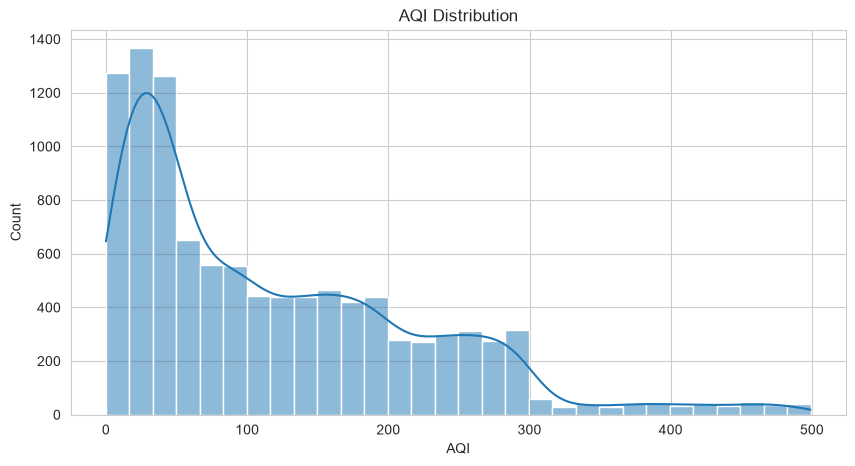

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(df["AQI"], bins=30, kde=True)

plt.title("AQI Distribution")

plt.savefig("../images/aqi_distribution.png")

plt.show()

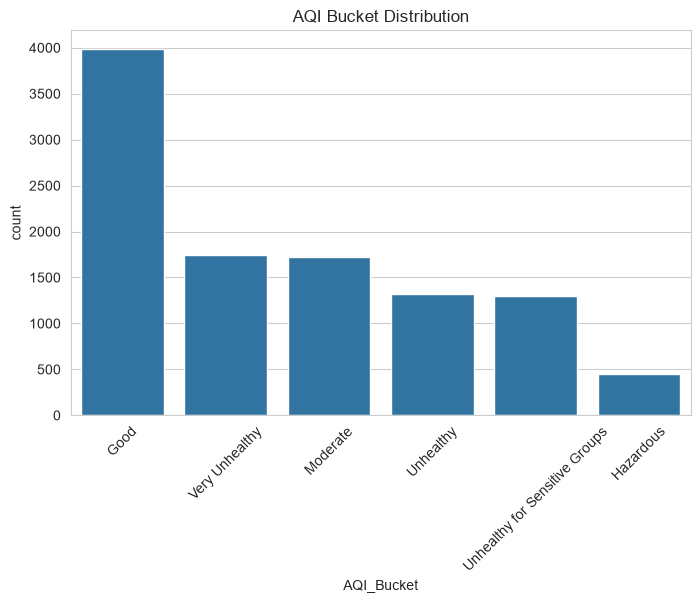

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index,
)

plt.xticks(rotation=45)

plt.title("AQI Bucket Distribution")

plt.savefig("../images/aqi_bucket_distribution.png")

plt.show()

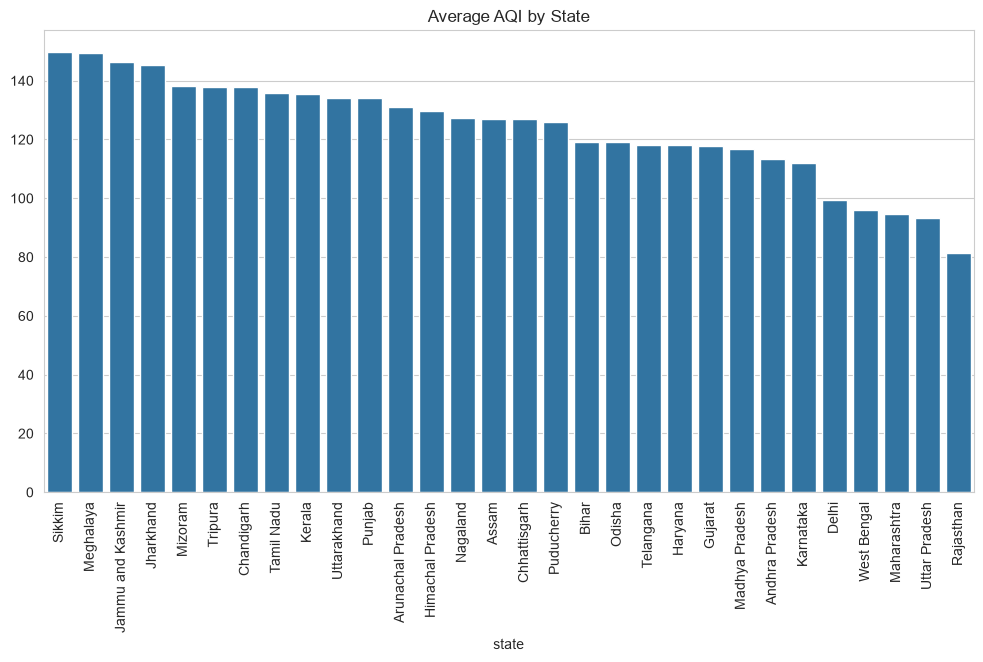

In [ ]:
state_aqi = (
    df.groupby("state")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=state_aqi.index,
    y=state_aqi.values,
)

plt.xticks(rotation=90)

plt.title("Average AQI by State")

plt.savefig("../images/state_aqi.png")

plt.show()

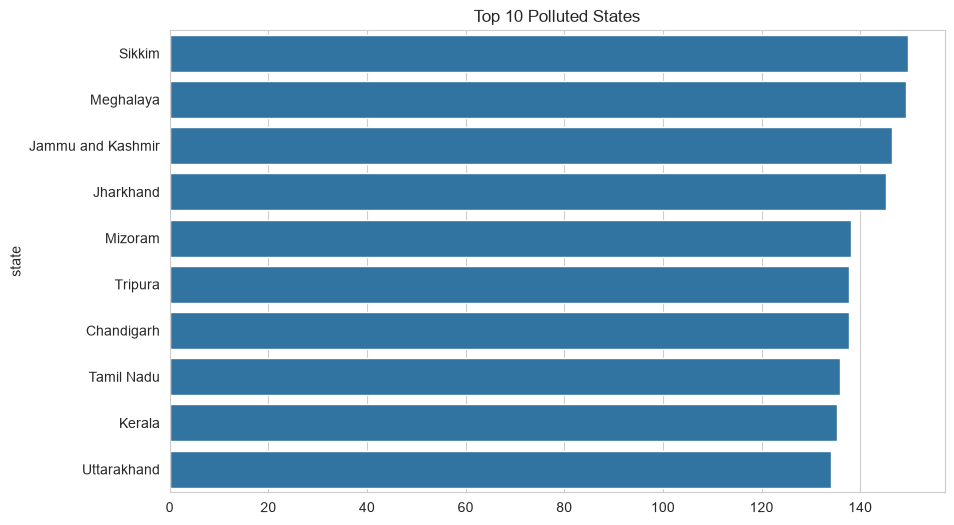

In [8]:
top_states = state_aqi.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
)

plt.title("Top 10 Polluted States")

plt.savefig("../images/top_polluted_states.png")

plt.show()

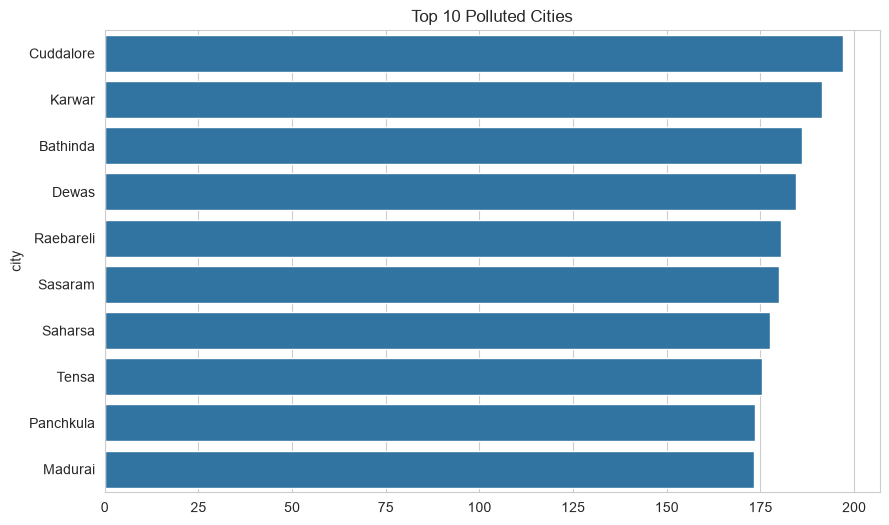

In [9]:
city_aqi = (
    df.groupby("city")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

top_cities = city_aqi.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
)

plt.title("Top 10 Polluted Cities")

plt.savefig("../images/top_polluted_cities.png")

plt.show()

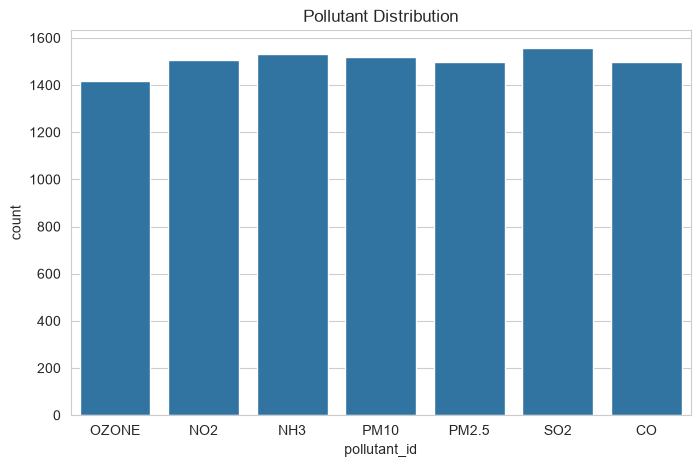

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="pollutant_id")

plt.title("Pollutant Distribution")

plt.savefig("../images/pollutant_distribution.png")

plt.show()

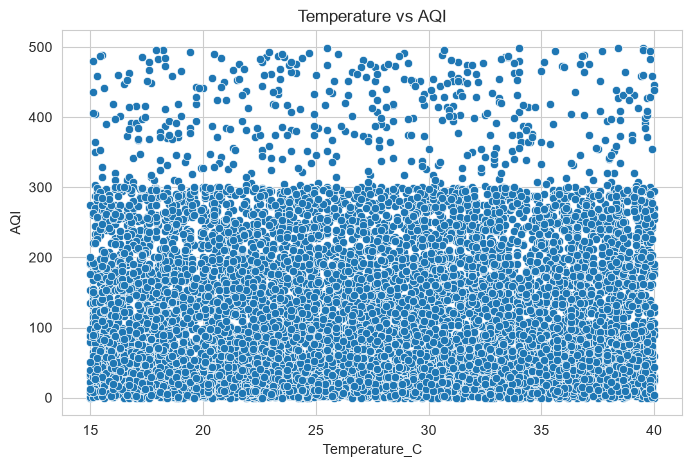

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temperature_C",
    y="AQI",
)

plt.title("Temperature vs AQI")

plt.savefig("../images/temp_vs_aqi.png")

plt.show()

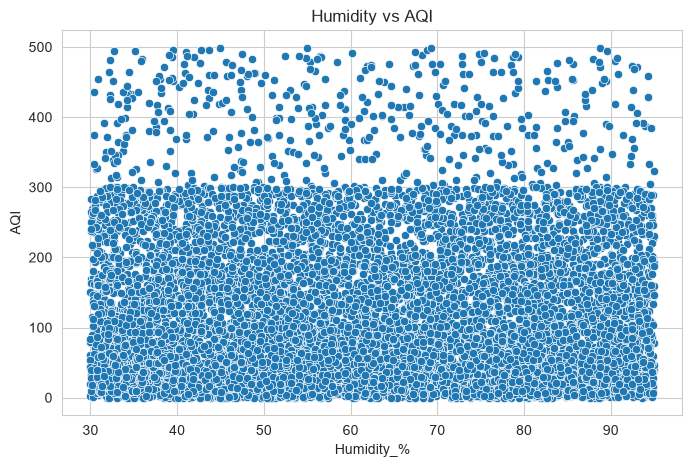

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Humidity_%",
    y="AQI",
)

plt.title("Humidity vs AQI")

plt.savefig("../images/humidity_vs_aqi.png")

plt.show()

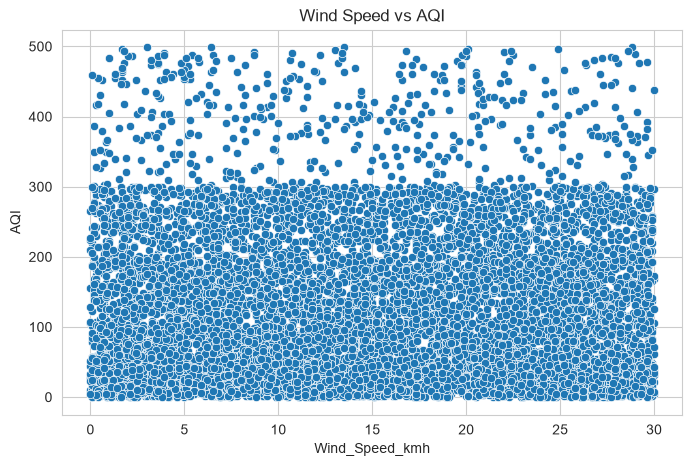

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Wind_Speed_kmh",
    y="AQI",
)

plt.title("Wind Speed vs AQI")

plt.savefig("../images/windspeed_vs_aqi.png")

plt.show()

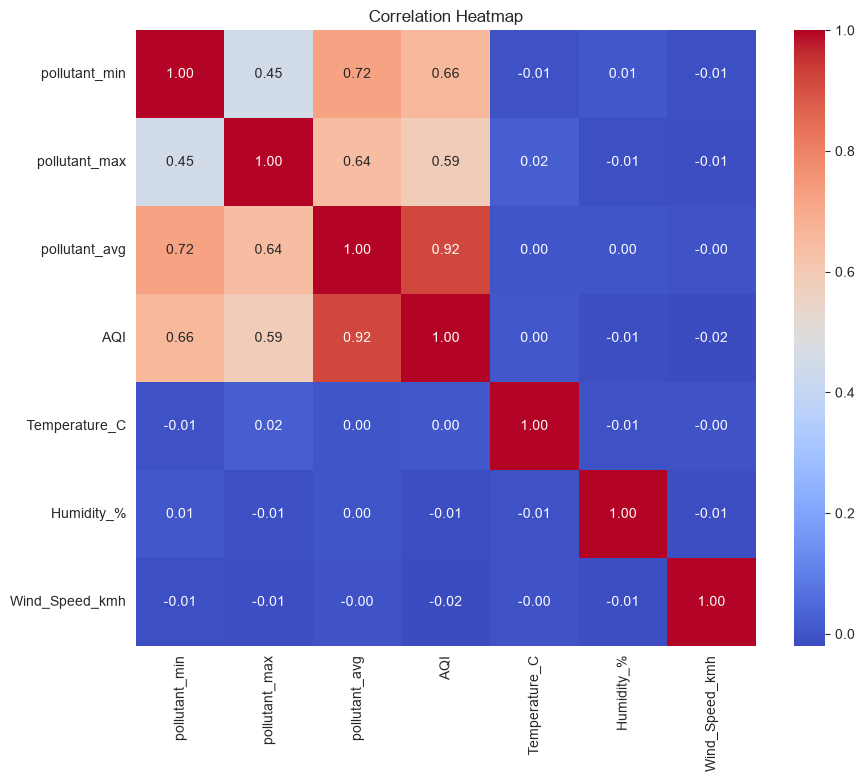

In [14]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")

plt.show()

In [15]:
fig = px.scatter(
    df,
    x="Temperature_C",
    y="AQI",
    color="AQI_Bucket",
    hover_data=["state", "city"],
    title="Temperature vs AQI",
)

fig.show()